In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Principal package imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint

,Unnamed: 0,user_id,course,textType,time,text,content-on_topic,content-plausible,content-convincing_ideas,content-scope,...,structure-coherence,structure-outline,structure-repetition,structure-text_pattern,language-clarity,language-spelling,language-puncutation,language-word_choice,language_sentence-structure,language_style
0,0,3203,5447,erzaehlung,1720779707,1. Versprochen!\n\nHanni und Ella waren beste ...,10,5,9,5,...,9.00000,4.00000,4.00000,5.00000,4,4,4,4,4,3
1,1,3203,5447,erzaehlung,1722615169,Lachen ist die beste Medizin\n\nIm Restaurant ...,10,5,9,5,...,9.00000,5.00000,4.00000,5.00000,5,4,4,5,4,4
2,2,3526,5447,erzaehlung,1722856654,"""Blöde Kuh? Vonwegen!""\n\nAn einem sonnigen Mo...",9,4,8,5,...,7.00000,4.00000,4.00000,4.00000,4,3,3,4,3,3
3,3,3526,5447,erzaehlung,1723017214,Versprochen!\nIch und Meine Freundin sind zusa...,2,4,6,4,...,6.00000,3.00000,3.00000,2.00000,3,2,2,3,3,2
4,4,3514,5447,erzaehlung,1723119172,Lachen ist die beste Medizin!\n\nIm Restaurant...,7,5,6,5,...,9.00000,4.00000,5.00000,5.00000,5,4,4,5,5,4


Temizlenmiş grading verisi boyutu: (1983, 20)


/tmp/ipykernel_122/28313332.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_bin_counts.index, y=user_bin_counts.values, palette='Blues_d')


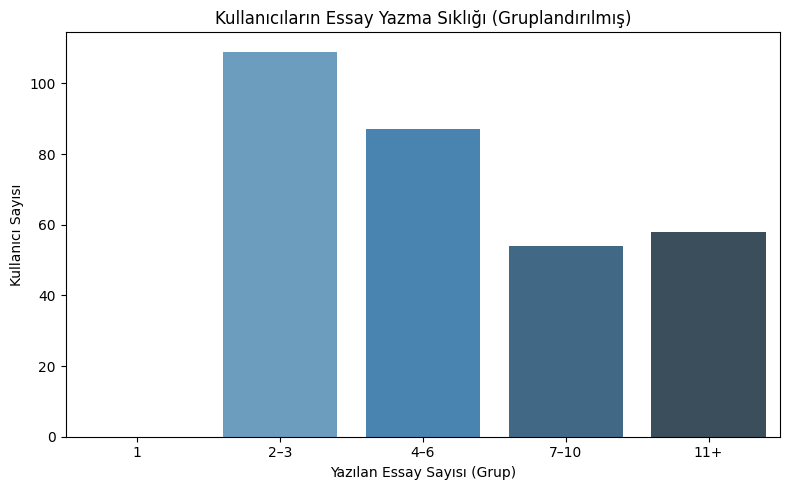

In [4]:
essay_res_df = pd.read_csv("/home/mlbd-project/updated_data/essay_results.csv")
display(essay_res_df.head())

# 2. 'content-correct' sütununu çıkar
essay_res_df = essay_res_df.drop(columns=["content-correct"])


# 4. structure-* sütunlarında eksik veri varsa sil
structure_columns = [col for col in essay_res_df.columns if col.startswith("structure-")]
essay_res_df = essay_res_df.dropna(subset=structure_columns)

# 5. Yeni boyutu kontrol et
print("Temizlenmiş grading verisi boyutu:", essay_res_df.shape)

# Kullanıcı başına essay sayısını al
user_essay_counts = essay_res_df['user_id'].value_counts()

# Bu sayılara göre kategorilere ayır (binleme)
bins = [0, 1, 3, 6, 10, user_essay_counts.max()+1]
labels = ['1', '2–3', '4–6', '7–10', '11+']
user_essay_bins = pd.cut(user_essay_counts, bins=bins, labels=labels, right=False)

# Bin başına kullanıcı sayısını görselleştir
user_bin_counts = user_essay_bins.value_counts().sort_index()

# Çizim
plt.figure(figsize=(8, 5))
sns.barplot(x=user_bin_counts.index, y=user_bin_counts.values, palette='Blues_d')
plt.title("Kullanıcıların Essay Yazma Sıklığı (Gruplandırılmış)")
plt.xlabel("Yazılan Essay Sayısı (Grup)")
plt.ylabel("Kullanıcı Sayısı")
plt.tight_layout()
plt.show()

In [5]:
# Grading sütunlarını tanımla
grading_columns = [
    "content-on_topic", "content-plausible", "content-convincing_ideas", "content-scope",
    "structure-coherence", "structure-outline", "structure-repetition", "structure-text_pattern",
    "language-clarity", "language-spelling", "language-puncutation",
    "language-word_choice", "language_sentence-structure", "language_style"
]

# Her kullanıcı için ortalama skorları hesapla
user_avg_grades = essay_res_df.groupby('user_id')[grading_columns].mean()

# Ortalama toplam grade hesapla (isteğe bağlı)
#user_avg_grades['avg_total_grade'] = user_avg_grades.mean(axis=1)

# İlk birkaç satırı göster
display(user_avg_grades)

,content-on_topic,content-plausible,content-convincing_ideas,content-scope,structure-coherence,structure-outline,structure-repetition,structure-text_pattern,language-clarity,language-spelling,language-puncutation,language-word_choice,language_sentence-structure,language_style
user_id,,,,,,,,,,,,,,
1,6.50000,4.00000,5.50000,3.50000,6.00000,3.00000,3.00000,3.00000,3.00000,2.00000,2.00000,3.00000,3.00000,2.00000
4,8.33333,4.00000,7.33333,4.33333,6.66667,3.33333,3.66667,3.66667,3.33333,3.00000,3.33333,3.33333,3.00000,2.33333
5,0.00000,0.00000,0.00000,0.00000,8.00000,4.00000,4.00000,4.00000,3.00000,4.00000,3.00000,3.00000,3.00000,2.00000
6,8.57143,4.00000,7.28571,4.42857,7.28571,3.57143,3.57143,3.85714,3.71429,2.85714,3.00000,3.57143,3.14286,2.42857
7,9.25000,4.25000,7.75000,4.50000,8.00000,4.00000,4.00000,4.50000,3.75000,3.00000,3.00000,3.50000,3.25000,2.75000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4086,9.16667,4.66667,7.66667,4.50000,8.33333,4.16667,4.16667,4.33333,4.33333,3.50000,3.66667,4.16667,4.00000,3.66667
4087,8.50000,4.00000,7.00000,4.00000,6.50000,3.00000,3.50000,3.50000,3.50000,3.00000,3.00000,3.50000,3.00000,2.50000
4089,8.00000,3.00000,6.00000,4.00000,5.00000,2.00000,3.00000,3.00000,2.00000,1.00000,1.00000,2.00000,2.00000,1.00000


In [6]:
dfall = user_avg_grades

In [7]:
display(dfall.shape)

(308, 14)

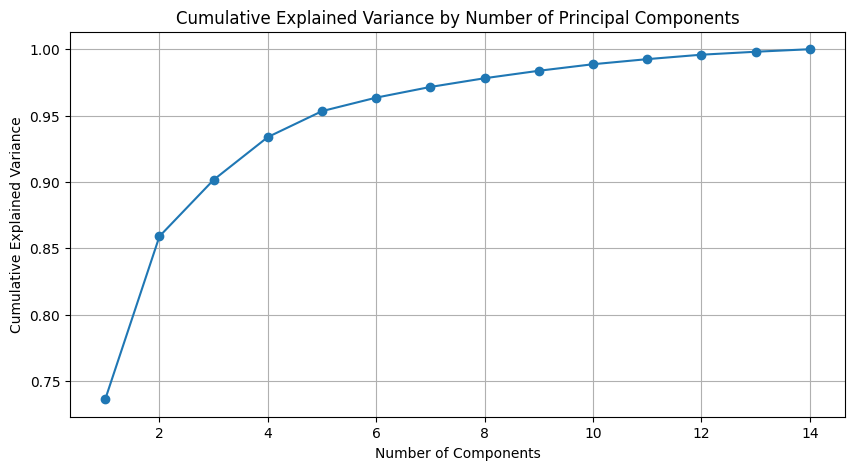


Key PCA Loadings (Top 5 features for the first 3 principal components):
              Top PC1 Features  PC1 Loadings          Top PC2 Features  \
0         language-word_choice       0.29207          content-on_topic   
1             language-clarity       0.28958  content-convincing_ideas   
2  language_sentence-structure       0.28750             content-scope   
3          structure-coherence       0.28640         language-spelling   
4            structure-outline       0.28341         content-plausible   

   PC2 Loadings        Top PC3 Features  PC3 Loadings  
0       0.46783          language_style       0.44758  
1       0.42030    structure-repetition       0.42900  
2       0.36883        language-clarity       0.34137  
3       0.34838    language-word_choice       0.33486  
4       0.33022  structure-text_pattern       0.32502  


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === 1. Select numeric columns ===
numeric_columns = dfall.select_dtypes(include=[np.number]).columns
X = dfall[numeric_columns].dropna()  # remove rows with missing values
#X = X.drop(columns=["user_id"])

# === 2. Standardize the data ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Apply PCA ===
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# === 4. Explained Variance Plot ===
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o')
plt.title("Cumulative Explained Variance by Number of Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# === 5. PCA Loadings Matrix ===
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numeric_columns
)

# === 6. Top contributing features for PC1, PC2, PC3 ===
top_features_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(5)
top_features_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(5)
top_features_pc3 = loadings["PC3"].abs().sort_values(ascending=False).head(5)

top_features_df = pd.DataFrame({
    "Top PC1 Features": top_features_pc1.index,
    "PC1 Loadings": top_features_pc1.values,
    "Top PC2 Features": top_features_pc2.index,
    "PC2 Loadings": top_features_pc2.values,
    "Top PC3 Features": top_features_pc3.index,
    "PC3 Loadings": top_features_pc3.values,
})

print("\nKey PCA Loadings (Top 5 features for the first 3 principal components):")
print(top_features_df)

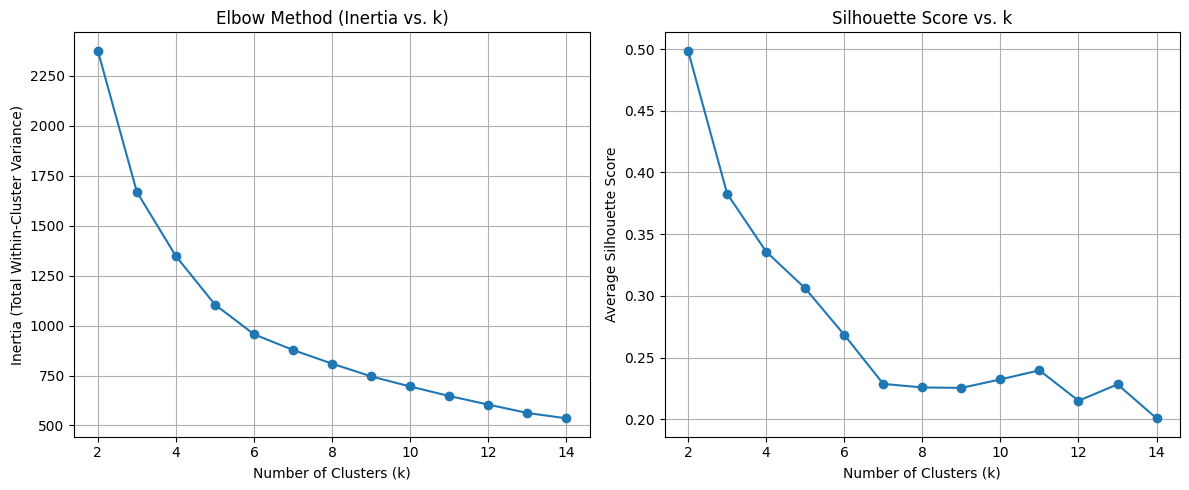

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# First 5 components from PCA-reduced data
X_pca_subset = X_pca[:, :7]

# Range of cluster numbers
K_range = range(2, 15)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_subset)
    
    # Elbow: total within-cluster variance (inertia)
    inertias.append(kmeans.inertia_)
    
    # Silhouette: quality of separation between clusters
    labels = kmeans.labels_
    score = silhouette_score(X_pca_subset, labels)
    silhouette_scores.append(score)

# === Plots ===
plt.figure(figsize=(12, 5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method (Inertia vs. k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Total Within-Cluster Variance)")
plt.grid(True)

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs. k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_eval = X_pca[:, :7]
k_values = [3, 4, 5]
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_eval)
    
    sil = silhouette_score(X_eval, labels)
    db = davies_bouldin_score(X_eval, labels)
    ch = calinski_harabasz_score(X_eval, labels)
    
    results.append({
        "k": k,
        "Silhouette Score (↑)": sil,
        "Davies-Bouldin (↓)": db,
        "Calinski-Harabasz (↑)": ch
    })

# Sonuçları tablo olarak göster
results_df = pd.DataFrame(results)
print(results_df)


   k  Silhouette Score (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
0  3               0.38281             0.90661              230.45778
1  4               0.33582             1.06287              213.77087
2  5               0.30611             0.92851              211.47976


In [11]:
from sklearn.cluster import KMeans

# İlk 6 PCA bileşenini al
X_pca_subset = X_pca[:, :7]

# KMeans kümeleme (k = 4 olarak seçildi)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_subset)

In [12]:
display(len(X_pca_subset))
display(dfall.info())

308

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 1 to 4095
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   content-on_topic             308 non-null    float64
 1   content-plausible            308 non-null    float64
 2   content-convincing_ideas     308 non-null    float64
 3   content-scope                308 non-null    float64
 4   structure-coherence          308 non-null    float64
 5   structure-outline            308 non-null    float64
 6   structure-repetition         308 non-null    float64
 7   structure-text_pattern       308 non-null    float64
 8   language-clarity             308 non-null    float64
 9   language-spelling            308 non-null    float64
 10  language-puncutation         308 non-null    float64
 11  language-word_choice         308 non-null    float64
 12  language_sentence-structure  308 non-null    float64
 13  language_style          

None

In [13]:
# Orijinal DataFrame'e cluster bilgisi ekle
df_clustered = dfall.copy()
df_clustered["Cluster"] = cluster_labels

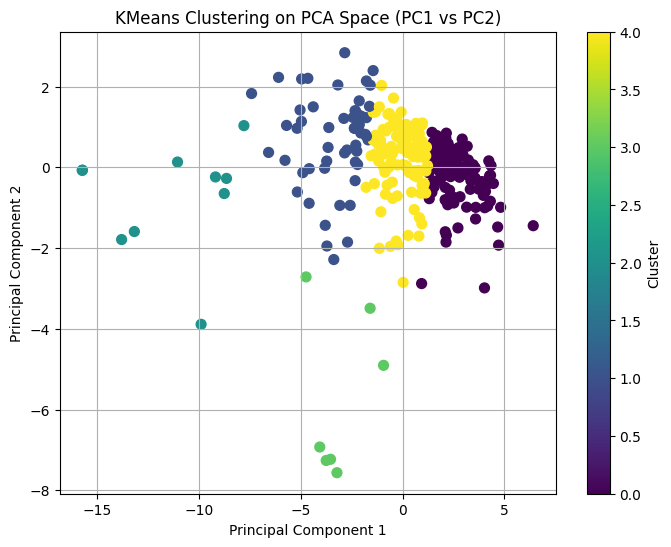

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title("KMeans Clustering on PCA Space (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")
plt.show()

In [15]:
# Sayısal sütunlar üzerinden kümelere göre ortalamaları hesapla
cluster_profiles = df_clustered.groupby("Cluster").mean(numeric_only=True)

# Sonuçları yazdır
print(cluster_profiles)

         content-on_topic  content-plausible  content-convincing_ideas  \
Cluster                                                                  
0                 8.71447            4.43286                   7.50420   
1                 6.87185            3.32515                   5.47487   
2                 1.78000            1.19000                   1.31000   
3                 1.44898            0.76871                   1.19218   
4                 7.99803            4.00724                   6.70835   

         content-scope  structure-coherence  structure-outline  \
Cluster                                                          
0              4.68532              8.07338            4.05592   
1              3.38488              5.14229            2.52185   
2              0.93500              2.12500            0.90000   
3              0.76871              7.53571            3.59694   
4              4.12626              6.90320            3.36121   

         structure

In [16]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# X_scaled: standardize edilmiş veri (PCA uygulanmış olabilir veya olmayabilir)
labels = kmeans.labels_

# 1. Silhouette Score
#sil_score = silhouette_score(X_scaled, labels)

# 2. Davies-Bouldin Index
#db_score = davies_bouldin_score(X_scaled, labels)

# 3. Calinski-Harabasz Index
#ch_score = calinski_harabasz_score(X_scaled, labels)

sil_score = silhouette_score(X_pca_subset, labels)
db_score = davies_bouldin_score(X_pca_subset, labels)
ch_score = calinski_harabasz_score(X_pca_subset, labels)

# Sonuçları yazdır
print(f"Silhouette Score:        {sil_score:.3f}  (↑ iyi)")
print(f"Davies-Bouldin Index:    {db_score:.3f}  (↓ iyi)")
print(f"Calinski-Harabasz Score: {ch_score:.3f}  (↑ iyi)")

Silhouette Score:        0.306  (↑ iyi)
Davies-Bouldin Index:    0.929  (↓ iyi)
Calinski-Harabasz Score: 211.480  (↑ iyi)


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def plot_cluster_radar_profiles(df_clustered, macro_columns, cluster_col="Cluster"):
    """
    Cluster profillerini hem unscaled hem scaled olarak radar plot'ta gösterir.

    Parameters:
    - df_clustered: Cluster bilgisi içeren DataFrame (ör: df_clustered)
    - macro_columns: Radar plot'ta kullanılacak sayısal özellikler (ör: ["Fat", "Protein", ...])
    - cluster_col: Cluster etiketini içeren kolon adı (varsayılan: "Cluster")
    """
    # Ortalama değerleri hesapla
    cluster_profiles = df_clustered.groupby(cluster_col)[macro_columns].mean()

    # Scale edilmiş versiyon
    scaler = MinMaxScaler()
    cluster_profiles_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_profiles),
        columns=cluster_profiles.columns,
        index=cluster_profiles.index
    )

    # Radar plot için ayarlar
    labels = macro_columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, axs = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True))

    # 1. Unscaled plot
    ax = axs[0]
    for i, row in cluster_profiles.iterrows():
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values, label=f"Cluster {i}", linewidth=2)
    ax.set_title("Unscaled Grades", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])

    # 2. Scaled plot
    ax = axs[1]
    for i, row in cluster_profiles_scaled.iterrows():
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values, label=f"Cluster {i}", linewidth=2)
    ax.set_title("Scaled Grades", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])

    plt.suptitle("Comparison of Cluster Essay Grades", size=16)
    plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
    plt.tight_layout()
    plt.show()

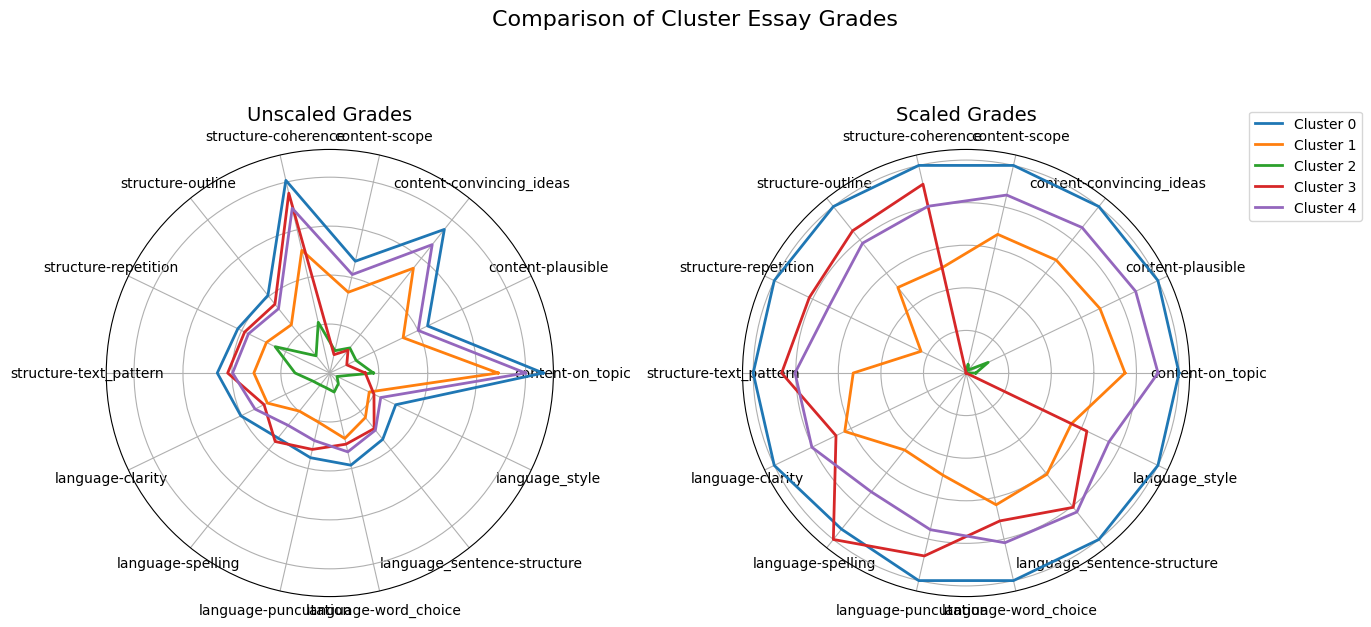

In [18]:
grading_columns = [
    "content-on_topic", "content-plausible", "content-convincing_ideas", "content-scope",
    "structure-coherence", "structure-outline", "structure-repetition", "structure-text_pattern",
    "language-clarity", "language-spelling", "language-puncutation",
    "language-word_choice", "language_sentence-structure", "language_style"
]
plot_cluster_radar_profiles(df_clustered, grading_columns)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def plot_cluster_radar_profiles(df_clustered, macro_columns, cluster_col="Cluster"):
    """
    Cluster profillerini hem unscaled hem scaled olarak radar plot'ta gösterir.
    """

    # Etiketleri düzenleme: Boşluk + büyük harf + uzun olanlara satır kırma
    def prettify_label(label):
        label = label.replace("_", " ").replace("-", " ").title()
        manual_breaks = {
            "Language Punctuation": "Language\nPunctuation",
            "Language Word Choice": "Language\nWord Choice",
            "Language Sentence Structure": "Language\nSentence Structure"
        }
        return manual_breaks.get(label, label)

    pretty_labels = [prettify_label(col) for col in macro_columns]

    # Cluster ortalamalarını al
    cluster_profiles = df_clustered.groupby(cluster_col)[macro_columns].mean()

    # Scale edilmiş versiyon
    scaler = MinMaxScaler()
    cluster_profiles_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_profiles),
        columns=cluster_profiles.columns,
        index=cluster_profiles.index
    )

    # Radar plot ayarları
    num_vars = len(pretty_labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    colors = plt.cm.tab10.colors  # max 10 renk destekler

    fig, axs = plt.subplots(1, 2, figsize=(15, 7), subplot_kw=dict(polar=True))

    # 1. Unscaled Plot
    ax = axs[0]
    for idx, (i, row) in enumerate(cluster_profiles.iterrows()):
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values,
                label=f"Cluster {i}",
                color=colors[idx % len(colors)],
                linestyle='solid',
                linewidth=2,
                alpha=0.9)
    ax.set_title("Unscaled Grades", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(pretty_labels, fontsize=9)
    ax.set_yticklabels([])

    # 2. Scaled Plot
    ax = axs[1]
    for idx, (i, row) in enumerate(cluster_profiles_scaled.iterrows()):
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values,
                label=f"Cluster {i}",
                color=colors[idx % len(colors)],
                linestyle='solid',
                linewidth=2,
                alpha=0.9)
    ax.set_title("Scaled Grades", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(pretty_labels, fontsize=9)
    ax.set_yticklabels([])

    # Ortak başlık ve legend
    plt.suptitle("Comparison of Cluster Essay Grades", size=16)
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12),
               ncol=cluster_profiles.shape[0], fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

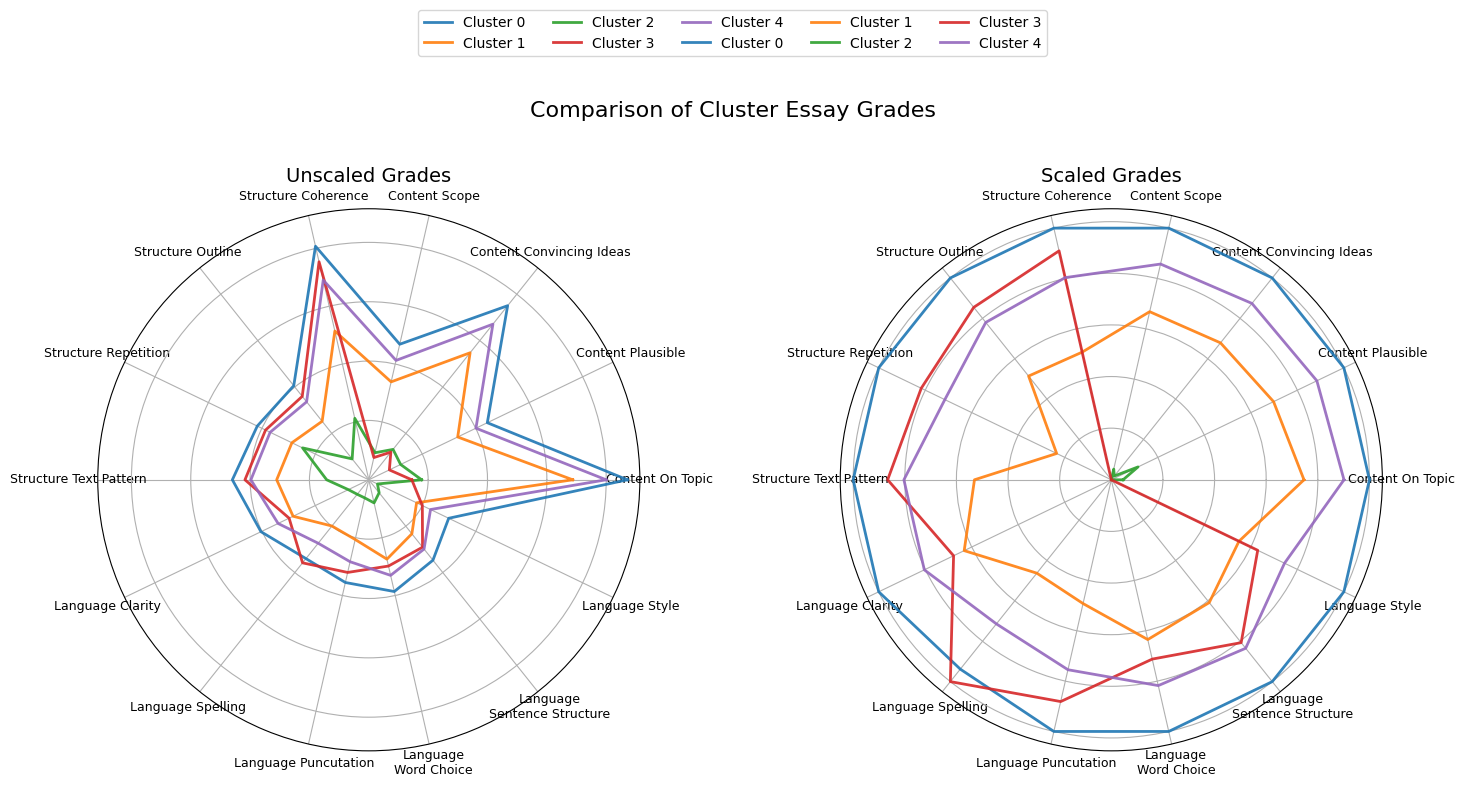

In [24]:
grading_columns = [
    "content-on_topic", "content-plausible", "content-convincing_ideas", "content-scope",
    "structure-coherence", "structure-outline", "structure-repetition", "structure-text_pattern",
    "language-clarity", "language-spelling", "language-puncutation",
    "language-word_choice", "language_sentence-structure", "language_style"
]
plot_cluster_radar_profiles(df_clustered, grading_columns)

In [98]:
# 1. Her bir kümede kaç örnek olduğunu say
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print(" Her kümedeki örnek sayısı:\n")
print(cluster_counts)

# 2. Her küme için tüm skorların ortalama değerlerini hesapla
cluster_means = df_clustered.groupby('Cluster').mean(numeric_only=True)

 Her kümedeki örnek sayısı:

Cluster
0    120
1     53
2     10
3      7
4    118
Name: count, dtype: int64


In [99]:
import pandas as pd

#  Gerekli CSV dosyalarını yükle
math_df = pd.read_csv("/home/mlbd-project/updated_data/math_results.csv")
text_df = pd.read_csv("/home/mlbd-project/updated_data/text_results.csv")

#  1. Her kullanıcı için matematik başarı yüzdesi
math_user_avg = math_df.groupby('user_id')[['points', 'max_points']].sum()
math_user_avg['math_percentage'] = math_user_avg['points'] / math_user_avg['max_points'] * 100
math_percentage = math_user_avg[['math_percentage']]

#  2. Her kullanıcı için metin başarı yüzdesi
text_user_avg = text_df.groupby('user_id')[['points', 'max_points']].sum()
text_user_avg['text_percentage'] = text_user_avg['points'] / text_user_avg['max_points'] * 100
text_percentage = text_user_avg[['text_percentage']]

#  3. Mevcut df_clustered ile eşleştirme (user_id index kabul edilerek)
# df_clustered'ın index'inin user_id olduğunu varsayıyoruz
df_combined = df_clustered.join(math_percentage, how='inner')
df_combined = df_combined.join(text_percentage, how='inner')

#  4. Cluster bazında ortalama başarıları hesapla
avg_performance_by_cluster = df_combined.groupby('Cluster')[['math_percentage', 'text_percentage']].mean().round(2)

#  5. Sonucu yazdır
print("Cluster bazında ortalama başarı yüzdeleri:\n")
print(avg_performance_by_cluster)

Cluster bazında ortalama başarı yüzdeleri:

         math_percentage  text_percentage
Cluster                                  
0               60.12000         42.44000
1               53.83000         42.69000
2               40.40000          6.82000
3               50.43000         46.55000
4               55.98000         49.20000


In [100]:
# 1. Her öğrenci için toplam essay sayısını bul
essay_counts = essay_res_df['user_id'].value_counts().rename('essay_count').to_frame()

# 2. İlk ve son essay ortalama puan farkını hesapla
grading_columns = [
    "content-on_topic", "content-plausible", "content-convincing_ideas", "content-scope",
    "structure-coherence", "structure-outline", "structure-repetition", "structure-text_pattern",
    "language-clarity", "language-spelling", "language-puncutation",
    "language-word_choice", "language_sentence-structure", "language_style"
]

# user_id + time'a göre sırala
essay_df_sorted = essay_res_df.sort_values(['user_id', 'time'])

# İlk ve son essay puanları
first_essays = essay_df_sorted.groupby('user_id').first()[grading_columns]
last_essays = essay_df_sorted.groupby('user_id').last()[grading_columns]

# Ortalama skorlarını al
first_avg = first_essays.mean(axis=1).rename('first_avg_score')
last_avg = last_essays.mean(axis=1).rename('last_avg_score')

# Gelişim farkı
score_change = (last_avg - first_avg).rename('score_change')

# 3. Essay sayısı ve gelişimi birleştir
essay_stats = pd.concat([essay_counts, score_change], axis=1)

# 4. df_clustered ile (user_id indexli) birleştir
df_combined = df_clustered[['Cluster']].join(essay_stats, how='inner')

# 5. Her Cluster için ortalama değerleri hesapla
cluster_summary = df_combined.groupby('Cluster')[['essay_count', 'score_change']].mean().round(2)

# Sonuç
print(cluster_summary)

         essay_count  score_change
Cluster                           
0            5.95000       0.35000
1            4.19000       0.46000
2            1.90000       0.16000
3            2.57000       0.35000
4            8.56000       0.29000


In [101]:
import pandas as pd

# Dosyaları yükle
# math_df = pd.read_csv("math_results.csv")  # veya math_results (1).csv
question_df = pd.read_csv("/home/mlbd-project/updated_data/math_questions_clean.csv")

# Sütunları eşle: math_df["question"] ile question_df["question_id"]
question_df = question_df.rename(columns={"question_id": "question", "skill_id": "subject"})
question_map_trimmed = question_df[['question', 'exam_id', 'subject']]

# Merge işlemi: subject bilgisini math_df'ye aktar
math_df = pd.merge(
    math_df,
    question_map_trimmed,
    on=['question', 'exam_id'],
    how='inner'
)

# Başarı oranını hesapla
math_df['correct_ratio'] = math_df['points'] / math_df['max_points'] * 100

# Her user + subject için ortalama başarı oranı
user_subject_score = math_df.groupby(['user_id', 'subject'])['correct_ratio'].mean().reset_index()

# df_clustered ile birleştir
df_clustered_reset = df_clustered.reset_index()[['user_id', 'Cluster']]
merged = pd.merge(user_subject_score, df_clustered_reset, on='user_id', how='inner')

# Sonuç: Cluster ve konuya göre ortalama başarı yüzdesi
cluster_topic_score = merged.groupby(['subject', 'Cluster'])['correct_ratio'].mean().unstack().round(2)

display(cluster_topic_score.T)

subject,Geometrie,Textaufgaben,Zahlen und Arithmetik
Cluster,,,
0,62.74000,66.28000,61.51000
1,54.13000,59.26000,61.16000
2,65.00000,49.92000,66.22000
3,30.54000,47.71000,46.82000
4,50.30000,64.03000,57.61000


In [65]:
merged.groupby(['Cluster', 'subject']).size().unstack()

subject,Geometrie,Textaufgaben,Zahlen und Arithmetik
Cluster,,,
0,63,93,95
1,76,115,118
2,20,25,25
3,3,6,8
